In [1]:
# Assignment Module 4(A + B)
# Machine Learning Fundamentals — Graded Assessment
# --- Q3. FEATURE ENGINEERING AND REGRESSION PIPELINE ---

In [2]:
!mkdir ../data
# Now upload the datasets provided

In [3]:
# --- Task 1 — DATA FEATURE ENGINEERING ---
print("--- Task 1: Date Feature Engineering ---\n")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df3 = pd.read_csv('../data/q3_retail_promotions.csv')
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])

df3['year'] = df3['transaction_date'].dt.year
df3['month'] = df3['transaction_date'].dt.month
df3['day_of_week'] = df3['transaction_date'].dt.dayofweek
df3['is_month_end'] = (df3['transaction_date'].dt.day >= 25).astype(int)

display(df3[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

--- Task 1: Date Feature Engineering ---



,transaction_date,year,month,day_of_week,is_month_end
1046,2024-08-19,2024,8,0,0
54,2022-02-07,2022,2,0,0
573,2023-07-18,2023,7,1,0
970,2024-06-18,2024,6,1,0
230,2022-07-13,2022,7,2,0


In [4]:
# --- Task 2 — TEMPORAL TRAIN-TEST SPLIT ---
print("--- Task 2: Temporal Train-Test Split ---\n")

df3 = df3.sort_values('transaction_date')

split_idx = int(len(df3) * 0.8)

train_df = df3.iloc[:split_idx]
test_df = df3.iloc[split_idx:]

print(f"Training records: {len(train_df)}")
print(f"Testing records: {len(test_df)}")

--- Task 2: Temporal Train-Test Split ---

Training records: 960
Testing records: 240


**Reasoning:** Random split is inappropriate here because it ignores the chronological order, leading to 'Data Leakage' where future data helps predict the past.

In [5]:
# --- Task 3 — PREPROCESSING PIPELINE ---
print("--- Task 3: Preprocessing Pipeline ---\n")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['competition_density', 'year', 'month', 'day_of_week']
cat_cols = ['promotion_type', 'location_type', 'store_size']

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train = train_df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
y_test = test_df['items_sold']

--- Task 3: Preprocessing Pipeline ---



--- Task 4: Model Training and Evaluation ---

--- Linear Regression ---
RMSE: 39.67
MAE:  29.36



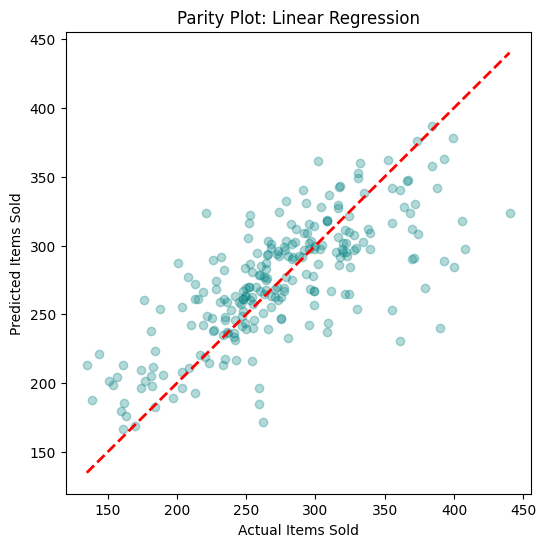

--- Random Forest ---
RMSE: 43.97
MAE:  34.59



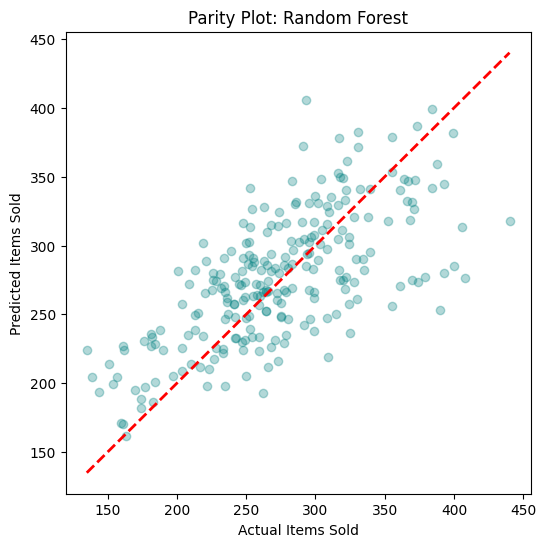

Top 5 Influential Features:
promotion_type_free_gift        0.180631
day_of_week                     0.167154
competition_density             0.130624
promotion_type_bogo             0.105038
promotion_type_flat_discount    0.102579
dtype: float64


In [7]:
# --- Task 4 — MODEL TRAINING AND EVALUATION ---
print("--- Task 4: Model Training and Evaluation ---\n")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Regression Pipelines
lr_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))])
rf_pipe.fit(X_train, y_train)

# Train and Evaluate
for name, pipeline in [("Linear Regression", lr_pipe), ("Random Forest", rf_pipe)]:
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}\n")

    # Parity Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds, alpha=0.3, color='teal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.title(f'Parity Plot: {name}')
    plt.show()



# Print Top 5 Influential Features (Random Forest)
rf_model = rf_pipe.named_steps['model']

cat_feature_names = rf_pipe.named_steps['prep'].transformers_[1][1].get_feature_names_out(cat_cols)
all_feature_names = list(cat_feature_names) + num_cols

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
print("Top 5 Influential Features:")
print(importances.sort_values(ascending=False).head(5))